In [18]:
# ==============================================================================
# 1. SETUP E IMPORTAÇÕES
# ==============================================================================
# Instalação do XGBoost caso não esteja presente no ambiente
%pip install xgboost -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import warnings

# Métricas e Validação cruzada (Reprodutibilidade garantida pelo random_state no split)
from sklearn.metrics import mean_squared_log_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split

# Preprocessamento e Pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Testes Estatísticos
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.feature_selection import f_regression
from scipy.stats import kruskal

import joblib

# Ignorar warnings visuais para manter o notebook limpo
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# ==============================================================================
# 2. CARREGAMENTO DOS DADOS E ANÁLISE DE NULOS
# ==============================================================================
df = pd.read_csv('./datasets/treino.csv')

# Engenharia de feature simples: Idade da casa no momento da venda
df['Idade_Casa'] = df['YrSold'] - df['YearBuilt']
print(f"Formato original dos dados: {df.shape}\n")

print("--- 1. Linhas Duplicadas ---")
print(f"Total de duplicatas: {df.duplicated().sum()}\n")

print("--- 2. Colunas Completamente Vazias ---")
colunas_vazias = df.columns[df.isnull().all()].tolist()
print(f"Colunas vazias: {colunas_vazias}\n")

print("--- 3. Top Colunas com mais Nulos ---")
nulos = df.isnull().sum()
nulos_percentual = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Total Nulos': nulos, '% Nulos': nulos_percentual})
print(df_nulos[df_nulos['Total Nulos'] > 0].sort_values(by='% Nulos', ascending=False).head(15))

Formato original dos dados: (1168, 82)

--- 1. Linhas Duplicadas ---
Total de duplicatas: 0

--- 2. Colunas Completamente Vazias ---
Colunas vazias: []

--- 3. Top Colunas com mais Nulos ---
              Total Nulos    % Nulos
PoolQC               1162  99.486301
MiscFeature          1122  96.061644
Alley                1094  93.664384
Fence                 935  80.051370
MasVnrType            683  58.476027
FireplaceQu           547  46.832192
LotFrontage           217  18.578767
GarageType             64   5.479452
GarageYrBlt            64   5.479452
GarageFinish           64   5.479452
GarageQual             64   5.479452
GarageCond             64   5.479452
BsmtCond               28   2.397260
BsmtFinType1           28   2.397260
BsmtExposure           28   2.397260


In [20]:
# ==============================================================================
# 3. LIMPEZA INICIAL (Remoção de colunas e Nulos com significado)
# ==============================================================================

# Definição de colunas que não agregam ao modelo (IDs ou redundantes)
COLUNAS_PARA_EXCLUIR = ['Id']

# Preenchimento de categóricas onde o valor "NA" não é erro, mas sim a ausência do item (ex: Sem Garagem)
PREENCHIMENTO_CATEGORICAS_CONHECIDAS = {
    'Alley': 'No alley access', 'BsmtQual': 'No Basement', 'BsmtCond': 'No Basement',
    'BsmtExposure': 'No Basement', 'BsmtFinType1': 'No Basement', 'BsmtFinType2': 'No Basement',
    'FireplaceQu': 'No Fireplace', 'GarageType': 'No Garage', 'GarageFinish': 'No Garage',
    'GarageQual': 'No Garage', 'GarageCond': 'No Garage', 'PoolQC': 'No Pool',
    'Fence': 'No Fence', 'MiscFeature': 'None', 'MasVnrType':'None'
}

df_limpo = df.copy()

# Remove colunas indesejadas
colunas_excluir_existentes = [col for col in COLUNAS_PARA_EXCLUIR if col in df_limpo.columns]
df_limpo = df_limpo.drop(columns=colunas_excluir_existentes)

# Aplica o preenchimento seguro
for col, valor_preenchimento in PREENCHIMENTO_CATEGORICAS_CONHECIDAS.items():
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].fillna(valor_preenchimento)

print(f"Valores nulos resolvidos com segurança: {df.isnull().sum().sum() - df_limpo.isnull().sum().sum()}")

Valores nulos resolvidos com segurança: 5939


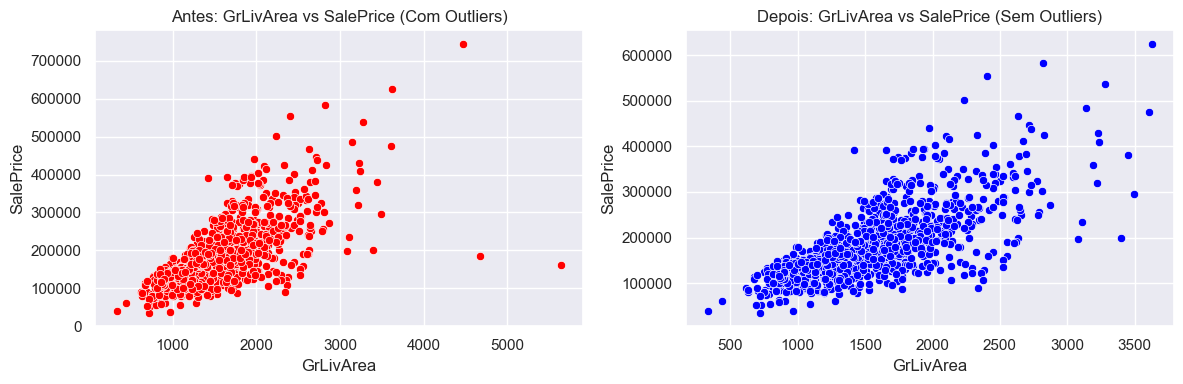

Tamanho do dataset DEPOIS de remover outliers: (1067, 81)


In [21]:
# ==============================================================================
# 4. TRATAMENTO DE OUTLIERS (Extremos e IQR)
# ==============================================================================

# -- VISUALIZAÇÃO ANTES DA REMOÇÃO --
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df_limpo['GrLivArea'], y=df_limpo['SalePrice'], color='red')
plt.title("Antes: GrLivArea vs SalePrice (Com Outliers)")

# Remoção de casas com área absurdamente grande (> 4000)
condicao_outlier_area = df_limpo['GrLivArea'] > 4000
df_limpo = df_limpo.drop(df_limpo[condicao_outlier_area].index)

# -- VISUALIZAÇÃO DEPOIS DA REMOÇÃO --
plt.subplot(1, 2, 2)
sns.scatterplot(x=df_limpo['GrLivArea'], y=df_limpo['SalePrice'], color='blue')
plt.title("Depois: GrLivArea vs SalePrice (Sem Outliers)")
plt.tight_layout()
plt.show()

# Aplicação do método IQR (Interquartile Range) para LotArea e TotalBsmtSF
COLUNAS_PARA_APLICAR_IQR = ['LotArea', 'TotalBsmtSF']

for col in COLUNAS_PARA_APLICAR_IQR:
    Q1 = df_limpo[col].quantile(0.25)
    Q3 = df_limpo[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Mantém apenas quem está dentro dos limites ou é nulo (para ser tratado depois)
    df_limpo = df_limpo[
        (df_limpo[col] >= limite_inferior) & (df_limpo[col] <= limite_superior) | 
        df_limpo[col].isnull()
    ]

print(f"Tamanho do dataset DEPOIS de remover outliers: {df_limpo.shape}")

In [22]:
# ==============================================================================
# 5. PREENCHIMENTO FINAL DE NULOS
# ==============================================================================

ESTRATEGIAS_NUMERICAS_POR_COLUNA = {
    'LotFrontage': 'mediana', 
    'MasVnrArea': 'zero',     
    'GarageYrBlt': 'zero'     
}

ESTRATEGIA_NUMERICA_PADRAO = 'mediana'
ESTRATEGIA_CATEGORICA_PADRAO = 'moda'

todas_numericas = df_limpo.select_dtypes(include=[np.number]).columns.tolist()
todas_categoricas = df_limpo.select_dtypes(exclude=[np.number]).columns.tolist()

# Aplicar nas colunas NUMÉRICAS
for col in todas_numericas:
    if df_limpo[col].isnull().sum() > 0:
        estr = ESTRATEGIAS_NUMERICAS_POR_COLUNA.get(col, ESTRATEGIA_NUMERICA_PADRAO)
        if estr == 'zero':
            df_limpo[col] = df_limpo[col].fillna(0)
        elif estr == 'media':
            df_limpo[col] = df_limpo[col].fillna(df_limpo[col].mean())
        elif estr == 'mediana':
            df_limpo[col] = df_limpo[col].fillna(df_limpo[col].median())

# Aplicar nas colunas CATEGÓRICAS restantes
for col in todas_categoricas:
    if df_limpo[col].isnull().sum() > 0:
        if ESTRATEGIA_CATEGORICA_PADRAO == 'moda':
            df_limpo[col] = df_limpo[col].fillna(df_limpo[col].mode()[0])
        elif ESTRATEGIA_CATEGORICA_PADRAO == 'ausente':
            df_limpo[col] = df_limpo[col].fillna('Ausente')

print(f"Total de nulos agora: {df_limpo.isnull().sum().sum()}")

Total de nulos agora: 0


In [ ]:
# ==============================================================================
# 6. ENCODING: CRIAÇÃO DOS DATASETS DE TESTE
# ==============================================================================
print("A gerar os datasets para o teste...\n")

target = 'SalePrice'
cols_num = [c for c in todas_numericas if c != target]
cols_cat = todas_categoricas

# --- VERSÃO 1: One-Hot Encoding ---
df_ohe = pd.get_dummies(df_limpo, columns=cols_cat, drop_first=True)
# df_ohe = OneHotEncoder(
#     handle_unknown='ignore',
#     sparse_output=False,
#     drop='first'
# )
# print(f"✅ Versão 1 (One-Hot Encoding) criada! Formato: {df_ohe.shape}")

# --- VERSÃO 2: Target Encoding ---
df_target = df_limpo.copy()
te = TargetEncoder(target_type='continuous', random_state=42)
df_target[cols_cat] = te.fit_transform(df_target[cols_cat], df_target[target])
print(f"✅ Versão 2 (Target Encoding) criada! Formato: {df_target.shape}")

# --- VERSÃO 3: Misto (ColumnTransformer) ---
cols_ohe_especifico = ['Foundation', 'GarageType', 'SaleCondition', 'MSZoning', 'CentralAir']
cols_ordinal_especifico = ['ExterQual', 'KitchenQual', 'BsmtQual']
cols_target_restante = [c for c in cols_cat if c not in cols_ohe_especifico and c not in cols_ordinal_especifico]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', cols_num),
        ('target', TargetEncoder(target_type='continuous', random_state=42), cols_target_restante),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cols_ohe_especifico),
        ('ord', OrdinalEncoder(), cols_ordinal_especifico)
    ]
)

X_misto_array = preprocessor.fit_transform(df_limpo.drop(target, axis=1), df_limpo[target])
nomes_colunas = (cols_num + cols_target_restante + 
                 preprocessor.named_transformers_['ohe'].get_feature_names_out(cols_ohe_especifico).tolist() + 
                 cols_ordinal_especifico)

df_misto_final = pd.DataFrame(X_misto_array, columns=nomes_colunas)
df_misto_final[target] = df_limpo[target].values
print(f"✅ Versão 3 (Misto) criada! Formato: {df_misto_final.shape}")

A gerar os datasets para o teste...



AttributeError: 'OneHotEncoder' object has no attribute 'shape'

In [ ]:
# ==============================================================================
# 7. ANÁLISE ESTATÍSTICA (Baseada no dataset com Target Encoding)
# ==============================================================================
# Utilizaremos o df_target pois ele transforma as categóricas em numéricas, permitindo rodar Pearson e VIF adequadamente.

df_teste_stats = df_target.copy()
X_stats = df_teste_stats.drop(columns=['SalePrice'])
y_stats = df_teste_stats['SalePrice']

print("="*60)
print("🔍 1. MATRIZ DE PEARSON (Pares com Alta Colinearidade > 0.75)")
print("="*60)
corr_matrix = X_stats.corr(method='pearson').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
alta_colinearidade = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i+1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > 0.75
]

if alta_colinearidade:
    for var1, var2, corr in sorted(alta_colinearidade, key=lambda x: x[2], reverse=True):
        print(f"⚠️ {var1:<15} e {var2:<15} | Correlação: {corr:.3f}")
else:
    print("✅ Nenhuma alta correlação direta encontrada!")

print("\n" + "="*60)
print("📊 2. TESTE VIF - MULTICOLINEARIDADE (Top 15)")
print("   (Regra geral: VIF > 10 indica problema grave)")
print("="*60)

X_vif = add_constant(X_stats) 
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_data.head(15).to_string(index=False))

print("\n" + "="*60)
print("🎯 3. TESTE F - IMPORTÂNCIA LINEAR (Top 10)")
print("="*60)
f_values, p_values_f = f_regression(X_stats, y_stats)
df_f_test = pd.DataFrame({'Feature': X_stats.columns, 'F_Score': f_values, 'P_Value': p_values_f})
df_f_test = df_f_test.sort_values(by='F_Score', ascending=False)
print(df_f_test.head(10).to_string(index=False))

print("\n" + "="*60)
print("🏷️ 4. TESTE H (Kruskal-Wallis) - CATEGÓRICAS (Top 10)")
print("="*60)
colunas_categoricas_originais = df_limpo.select_dtypes(exclude=[np.number]).columns
h_results = []

for col in colunas_categoricas_originais:
    grupos = [grupo['SalePrice'].values for nome, grupo in df_limpo.groupby(col)]
    if len(grupos) > 1:
        stat, p_value_h = kruskal(*grupos)
        h_results.append({'Feature': col, 'H_Statistic': stat, 'P_Value': p_value_h})

df_h_test = pd.DataFrame(h_results).sort_values(by='H_Statistic', ascending=False)
print(df_h_test.head(10).to_string(index=False))

🔍 1. MATRIZ DE PEARSON (Pares com Alta Colinearidade > 0.75)
⚠️ YearBuilt       e Idade_Casa      | Correlação: 0.999
⚠️ Street          e Utilities       | Correlação: 0.999
⚠️ Exterior1st     e Exterior2nd     | Correlação: 0.923
⚠️ SaleType        e SaleCondition   | Correlação: 0.900
⚠️ GarageCars      e GarageArea      | Correlação: 0.887
⚠️ GarageQual      e GarageCond      | Correlação: 0.881
⚠️ TotalBsmtSF     e 1stFlrSF        | Correlação: 0.872
⚠️ GarageYrBlt     e GarageCond      | Correlação: 0.853
⚠️ GrLivArea       e TotRmsAbvGrd    | Correlação: 0.833
⚠️ GarageYrBlt     e GarageQual      | Correlação: 0.831
⚠️ Fireplaces      e FireplaceQu     | Correlação: 0.820

📊 2. TESTE VIF - MULTICOLINEARIDADE (Top 15)
   (Regra geral: VIF > 10 indica problema grave)
     Feature        VIF
  BsmtFinSF1        inf
  BsmtFinSF2        inf
 TotalBsmtSF        inf
   BsmtUnfSF        inf
LowQualFinSF        inf
      YrSold        inf
  Idade_Casa        inf
    2ndFlrSF        inf
 

⏳ A gerar os gráficos de correlação...


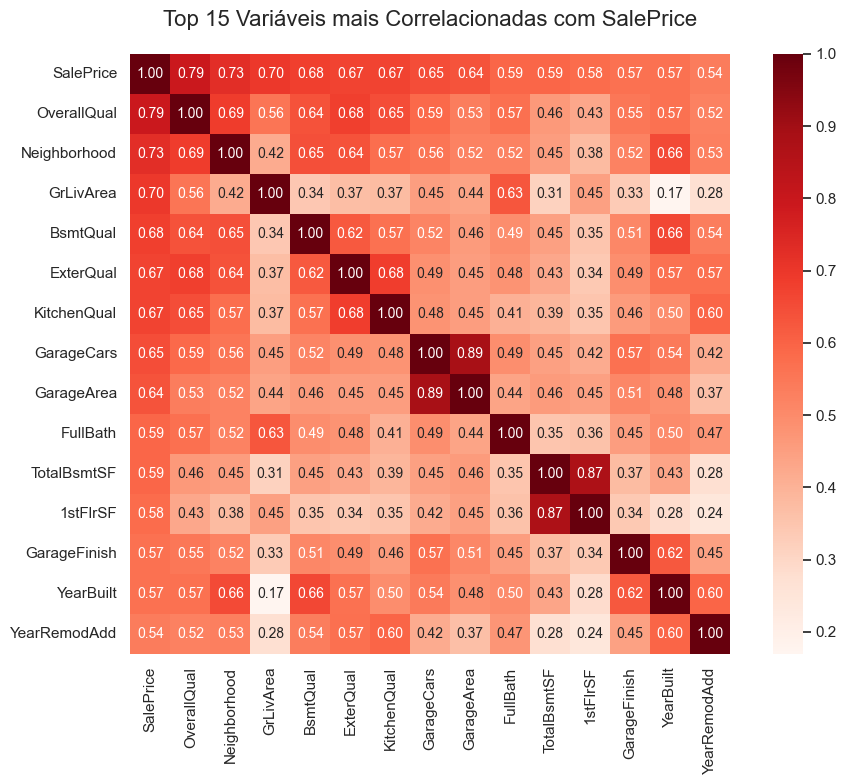

In [ ]:
# ==============================================================================
# 8. VISUALIZAÇÃO: MATRIZ DE CORRELAÇÃO DE PEARSON
# ==============================================================================


corr_matrix_full = df_teste_stats.corr(method='pearson')

print("⏳ A gerar os gráficos de correlação...")

# --- GRÁFICO 1: Zoom nas Variáveis mais correlacionadas com 'SalePrice' ---
plt.figure(figsize=(10, 8))

k = 15 
cols_top = corr_matrix_full.nlargest(k, 'SalePrice')['SalePrice'].index
cm_top = np.corrcoef(df_teste_stats[cols_top].values.T)

sns.set(font_scale=1.0)
hm = sns.heatmap(cm_top, cbar=True, annot=True, square=True, fmt='.2f', 
                 annot_kws={'size': 10}, yticklabels=cols_top.values, 
                 xticklabels=cols_top.values, cmap='Reds')

plt.title(f'Top {k} Variáveis mais Correlacionadas com SalePrice', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 9. DEFINIÇÃO DOS MODELOS E FUNÇÃO DE AVALIAÇÃO
# ==============================================================================

modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42),
    "Floresta Aleatória": RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=5, max_features='sqrt', random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=9, weights="distance", metric='manhattan'),
    "SVM": SVR(kernel='rbf', C=10, epsilon=0.1),
    "Ensemble (GBM)": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42),
    "Ridge Regression": Ridge(alpha=15.0),
    "Lasso Regression": Lasso(alpha=0.0, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4, colsample_bytree=0.8, subsample=0.8, random_state=42)
}

def avaliar_completo_customizado(nome_versao, df_dados):
    if 'SalePrice' not in df_dados.columns:
        print(f"❌ Erro na {nome_versao}: Coluna 'SalePrice' não encontrada!")
        return

    print(f"\n{'='*120}")
    print(f"{nome_versao}")
    print(f"{'='*120}")
    
    X = df_dados.drop(columns=['SalePrice'])
    y = df_dados['SalePrice']
    
    # Reprodutibilidade: random_state=42 garante o mesmo split de treino/teste sempre
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Transformação logarítmica da variável alvo para estabilizar variância
    y_train_log = np.log1p(y_train)
    
    print(f"{'Modelo':<20} | {'RMSE Treino':<12} | {'RMSE Teste':<12} | {'RMSLE Treino':<12} | {'RMSLE Teste':<12} | {'R² Treino':<9} | {'R² Teste':<8} |")
    print("-" * 120)
    
    for nome, modelo in modelos.items():
        try:
            modelo.fit(X_train_scaled, y_train_log)
            
            # Predição Treino
            preds_train_log = modelo.predict(X_train_scaled)
            preds_train_reais = np.clip(np.expm1(preds_train_log), a_min=0, a_max=None)
            rmse_train = np.sqrt(mean_squared_error(y_train, preds_train_reais))
            rmsle_train = np.sqrt(mean_squared_log_error(y_train, preds_train_reais))
            r2_train = r2_score(y_train, preds_train_reais)
            
            # Predição Teste
            preds_val_log = modelo.predict(X_val_scaled)
            preds_val_reais = np.clip(np.expm1(preds_val_log), a_min=0, a_max=None)
            rmse_val = np.sqrt(mean_squared_error(y_val, preds_val_reais))
            rmsle_val = np.sqrt(mean_squared_log_error(y_val, preds_val_reais))
            r2_val = r2_score(y_val, preds_val_reais)
            
            print(f"{nome:<20} | ${rmse_train:>10,.0f} | ${rmse_val:>10,.0f} | {rmsle_train:.5f}      | {rmsle_val:.5f}      | {r2_train:.4f}    | {r2_val:.4f}   |")
        except Exception as e:
            print(f"{nome:<20} | Erro: {str(e)[:50]}")

# ==============================================================================
# EXECUÇÃO FINAL
# ==============================================================================
avaliar_completo_customizado("TESTE 1: ONE-HOT ENCODING", df_ohe)
avaliar_completo_customizado("TESTE 2: TARGET ENCODING (ALL CATS)", df_target)
avaliar_completo_customizado("TESTE 3: ESTRATÉGIA MISTA (ORD/OHE/TARGET)", df_misto_final)


TESTE 1: ONE-HOT ENCODING
Modelo               | RMSE Treino  | RMSE Teste   | RMSLE Treino | RMSLE Teste  | R² Treino | R² Teste |
------------------------------------------------------------------------------------------------------------------------
Regressão Linear     | $    15,300 | $    16,582 | 0.08548      | 0.11002      | 0.9495    | 0.9290   |
Árvore de Decisão    | $    17,353 | $    28,580 | 0.09431      | 0.18540      | 0.9351    | 0.7892   |
Floresta Aleatória   | $    14,553 | $    20,407 | 0.07254      | 0.12227      | 0.9543    | 0.8925   |
KNN                  | $         0 | $    25,890 | 0.00000      | 0.14980      | 1.0000    | 0.8270   |
SVM                  | $    14,209 | $    29,163 | 0.07505      | 0.16501      | 0.9565    | 0.7805   |
Ensemble (GBM)       | $     3,815 | $    16,958 | 0.02093      | 0.10884      | 0.9969    | 0.9258   |
Ridge Regression     | $    15,370 | $    15,203 | 0.08709      | 0.10065      | 0.9491    | 0.9404   |
Lasso Regression  

In [ ]:

X_final = df_ohe.drop(columns=['SalePrice'])
y_final = df_ohe['SalePrice']

scaler = StandardScaler()

# # Teste
# X_train, X_val, y_train, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

# y_train_log = np.log1p(y_train)

# modelo_final = Lasso(alpha=0.002, random_state=42)

# modelo_final.fit(X_train_scaled, y_train_log)

# print(f"{'RMSE Treino':<11} | {'RMSE Teste':<11} | {'RMSLE Treino':<11} | {'RMSLE Teste':<11} | {'R² Treino':<10} | {'R² Teste':<9} |")
# print("-" * 120)
            
# # Predição Treino
# preds_train_log = modelo_final.predict(X_train_scaled)
# preds_train_reais = np.clip(np.expm1(preds_train_log), a_min=0, a_max=None)
# rmse_train = np.sqrt(mean_squared_error(y_train, preds_train_reais))
# rmsle_train = np.sqrt(mean_squared_log_error(y_train, preds_train_reais))
# r2_train = r2_score(y_train, preds_train_reais)

# # Predição Teste
# preds_val_log = modelo_final.predict(X_val_scaled)
# preds_val_reais = np.clip(np.expm1(preds_val_log), a_min=0, a_max=None)
# rmse_val = np.sqrt(mean_squared_error(y_val, preds_val_reais))
# rmsle_val = np.sqrt(mean_squared_log_error(y_val, preds_val_reais))
# r2_val = r2_score(y_val, preds_val_reais)
            
# print(f"${rmse_train:>10,.0f} | ${rmse_val:>10,.0f} | {rmsle_train:.5f}      | {rmsle_val:.5f}      | {r2_train:.4f}    | {r2_val:.4f}   |")
# #FIM TESTE


X_train_scaled = scaler.fit_transform(X_final)

y_train_log = np.log1p(y_final)

modelo_final = Lasso(alpha=0.002, random_state=42)

modelo_final.fit(X_train_scaled, y_train_log)

joblib.dump(modelo_final, 'modelo_lasso_ohe.joblib')
joblib.dump(scaler, 'scaler_lasso_ohe.joblib')



['scaler_lasso_ohe.joblib']

In [ ]:
# print(X_train_scaled)
print(X_final)

      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0             20         70.0     8400            5            6       1957   
1             60         59.0     7837            6            7       1993   
2             30         67.0     8777            5            7       1910   
3             50         60.0     7200            5            7       1937   
4             50         50.0     5000            5            6       1924   
...          ...          ...      ...          ...          ...        ...   
1163          20         78.0     9317            6            5       2006   
1164          50         65.0     7804            4            3       1928   
1165          20         60.0     8172            5            7       1955   
1166          50         55.0     7642            7            8       1918   
1167         120         53.0     3684            7            5       2007   

      YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFin